## Muraro Pancreatic Dataset

The Muraro human pancreas scRNA-seq expression matrix was obtained from the NCBI Gene Expression Omnibus (GEO), accession **GSE85241**. The supplementary matrix `GSE85241_cellsystems_dataset_4donors_updated.csv.gz` was downloaded directly from GEO and converted to AnnData for downstream analysis.

The dataset was generated using **CEL-seq2**. The supplied expression matrix contains both integer and non-integer values (78.84% and 21.16%, respectively). Therefore, the matrix was used as supplied rather than assuming that all entries represent integer-valued raw counts.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

True

In [3]:
from pathlib import Path
from src import muraro_data as md
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import scanpy as sc
import pandas as pd
from src import muraro_preprocessing as mp
from src import clustering as cl
from src import new_evaluation as ev
from src import optimization as opt
from src import visualisation as viz
from src import marker as mk
from src.graph import graph
import src.openAI_llm as lm
from src.agent import cluster_node, evaluate_node, reflection_node, final_selection_node
from src.decision import (OptimizationDecision, FinalExperimentSelection,)
from src.wt_biology_prompts import (
    build_biology_reflection_prompt,
    build_biology_final_selection_prompt,
    MURARO_BIOLOGICAL_CONTEXT,)
from src.experiment_logger import (create_experiment_log,save_experiment_log,add_final_result,)

from langchain_openai.chat_models import ChatOpenAI 
from IPython.display import Image, display

## Muraro Dataset Loading

The Muraro expression matrix was converted to an AnnData object for downstream Scanpy analysis.

In [4]:
# Download Muraro expression data if needed
muraro_expression_file = md.download_muraro_expression()

# Create the AnnData file if it does not already exist
muraro_h5ad = Path("data/muraro/muraro_raw.h5ad")

if not muraro_h5ad.exists():
    md.create_muraro_h5ad(
        muraro_expression_file,
        output_file=muraro_h5ad
    )

# Load Muraro expression data
muraro = md.load_muraro_expression()

## Reference Annotations

Reference cell-type annotations were obtained using the Bioconductor **scRNAseq** package and its `MuraroPancreasData()` dataset. The annotation labels were exported from the R/Bioconductor object and saved as `data/muraro/muraro_cell_annotations.csv`.

The annotation file was then matched to the expression data by cell ID and attached to the AnnData object. These reference labels are used only for post-hoc external evaluation and are not provided to the optimization agent.

In [5]:
muraro_annotations = md.load_muraro_annotations()

muraro = md.attach_reference_annotations(
    muraro,
    muraro_annotations
)

## QC Distribution

QC metrics are calculated on a copy of the raw data to visualize gene detection and total expression before preprocessing. 

#### QC Considerations

Gene detection was relatively high, with a median of **4,509 genes per cell** and a 75th percentile of **5,822 genes per cell**. Therefore, the PBMC3k-specific upper gene-detection threshold was not applied to the Muraro dataset.

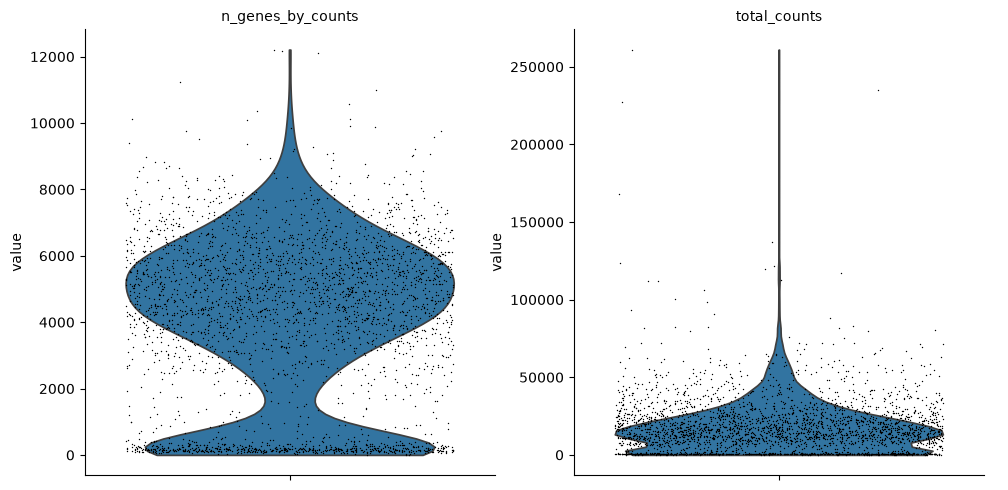

In [6]:
muraro_qc = muraro.copy()

sc.pp.calculate_qc_metrics(
    muraro_qc,
    inplace=True,
)

sc.pl.violin(
    muraro_qc,
    ["n_genes_by_counts", "total_counts"],
    multi_panel=True,
    jitter=0.4,
)

## Fixed Preprocessing

The same preprocessing pipeline is applied to all Muraro cells before agent optimization.

+ Quality control removes genes detected in fewer than **3 cells** and cells with **≤200 detected genes**. Mitochondrial QC is not applied because the dataset contains no mitochondrial genes.

+ Expression is normalized to a total of **10,000 counts per cell** and log-transformed.

+ **2,000 highly variable genes** are selected using the **Cell Ranger** method. The supplied expression matrix contains both integer and non-integer values; therefore, the Seurat v3 HVG method, which is intended for raw count data, was not used.

+ Total counts are regressed out as a technical effect, followed by scaling and PCA.

In [7]:
# Preprocess first
muraro_processed = mp.run_preprocessing_pipeline(
    muraro.copy()
)

Running Muraro QC...
Running normalization...
Running PCA...
Finished Muraro preprocessing.


In [8]:
print(muraro_processed.obs["cell_type_reference"].value_counts(dropna=False))

cell_type_reference
alpha          812
NaN            554
beta           448
duct           245
acinar         219
delta          193
pp             101
mesenchymal     80
endothelial     21
unclear          4
epsilon          3
Name: count, dtype: int64


## Reference-Based Evaluation Subset

Of the 3,072 cells, 946 have no reference label and 4 are labelled `unclear`. Only cells with usable reference annotations are included in reference-based evaluation. The agent still clusters the full preprocessed dataset.

The agent optimizes clustering using the full preprocessed Muraro dataset.  

For external validation, a separate evaluation subset is created containing only cells with valid published reference annotations. Cells with missing or `"unclear"` reference labels are excluded.

This separation ensures that reference labels are used for **post-hoc evaluation** rather than during the clustering optimization.

In [9]:
# Then create evaluation subset from processed data
muraro_eval = md.get_evaluation_subset(
    muraro_processed)

In [10]:
print(muraro)
print(muraro_processed.shape)
print(muraro_eval.shape)

AnnData object with n_obs × n_vars = 3072 × 19140
    obs: 'cell_type_reference'
(2680, 2000)
(2122, 2000)


In [11]:
print("Expression cells:", muraro.shape[1])
print("Annotation cells:", muraro_annotations.shape[0])
print(
    "All cell IDs match:",
    set(muraro.obs_names) == set(muraro_annotations["cell_id"])
)

Expression cells: 19140
Annotation cells: 3072
All cell IDs match: True


In [12]:
print(muraro_eval.obs["cell_type_reference"].value_counts(dropna=False))

cell_type_reference
alpha          812
beta           448
duct           245
acinar         219
delta          193
pp             101
mesenchymal     80
endothelial     21
epsilon          3
Name: count, dtype: int64


## Agent State Setup
The state acts as the agent's shared memory. Technically, LangGraph simply gives every node the same shared memory. Each node:

+ reads what it needs
+ updates what changed
+ returns the updated state

In this setup, it stores the dataset, current parameters, evaluation metrics, experiment history, and optimization progress, allowing each node in the LangGraph workflow to access the information it needs and update it as the optimization proceeds.


In [13]:
agent_adata = muraro_processed.copy()

In [14]:
experiment_log = create_experiment_log(
    experiment_id="EXP-035",
    dataset="Muraro",
    method="agentic_biology",
    condition="biology",
    agent_version="v0.7-reproducibility",
    llm_seed=lm.LLM_SEED,
    change=(
        "Applied the existing agentic optimization framework to the "
        "Muraro human pancreas scRNA-seq dataset as an external "
        "generalization experiment."
    ),
    reason_for_change=(
        "To evaluate the agent's optimization behaviour on an external "
        "dataset while limiting the biological information available "
        "to the LLM."
    ),
)

In [15]:
state = {
    "messages": [],

    "adata": agent_adata,

    "parameters": {
        "n_neighbors": 15,
        "resolution": 1.0,
        "n_pcs": 20,
    },

    "condition": "biology",

    "metrics": {},

    "history": [],

    "experiment_log": experiment_log,

    "iteration": 0,

    "decision": "continue",

    "reason": "",

    "evaluated_configs": [],

    "clustering_time": 0.0,

    "evaluation_time": 0.0,

    "llm_decision_time": 0.0,

    "selected_iteration": None,

    "best_experiment": None,

    "final_selection_reason": None,

    "final_selection_time": 0.0,
}

### Run Agentic Optimization

The following cell executes the agentic optimization workflow using the specified initial state and saves the resulting experiment log.

The agent will iteratively:
- run clustering,
- evaluate the clustering,
- request an LLM reflection/parameter decision,
- continue until the exploration budget is reached or the LLM decides to stop,
- and finally select the preferred experiment from the completed history.


In [16]:
result = graph.invoke(state)

save_experiment_log(result["experiment_log"])


CURRENT EVALUATION
Clusters: 19
Silhouette: 0.1732
DBI: 1.6796
WC-dispersion: 572764.1250
Banfield-Raftery: 13277.4697

LLM PROMPT

You are an expert in single-cell RNA-seq clustering optimization.

Your objective is to explore clustering parameters and identify
parameter configurations that provide strong overall clustering
evidence while avoiding unnecessary over-fragmentation or
under-clustering.

The optimization should balance potential improvement against the
cost of additional experiments.

BIOLOGY-INFORMED EXPERIMENTAL CONDITION:

This is a biology-informed clustering optimization experiment.

The optimization uses three sources of information:

1. intrinsic clustering metrics,
2. cluster structure, and
3. limited biological evidence from marker genes.

These sources of information have different roles.

Intrinsic clustering metrics are the primary quantitative evidence.

Cluster structure is secondary structural evidence used to interpret
the clustering solution.

Marker gene

PosixPath('experiments/EXP-035.json')

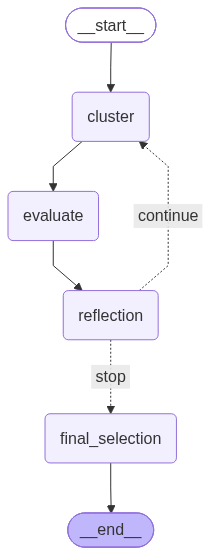

In [17]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
for experiment in result["history"]:
    print("\nIteration:", experiment["iteration"])
    print("Parameters:", experiment["parameters"])
    print("Metrics:", experiment["metrics"])


Iteration: 0
Parameters: {'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20}
Metrics: {'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20, 'random_state': 42, 'n_clusters': 19, 'cluster_sizes': {'0': 248, '1': 255, '2': 22, '3': 196, '4': 254, '5': 148, '6': 261, '7': 192, '8': 22, '9': 233, '10': 44, '11': 6, '12': 92, '13': 159, '14': 83, '15': 202, '16': 10, '17': 142, '18': 111}, 'largest_cluster_size': 261, 'largest_cluster_fraction': 0.09738805970149254, 'number_of_small_clusters': 5, 'small_clusters': {'2': 22, '8': 22, '10': 44, '11': 6, '16': 10}, 'silhouette_score': 0.17319414019584656, 'davies_bouldin_score': 1.6795932797328401, 'wc_dispersion_score': 572764.125, 'banfield_raftery_score': 13277.4697265625, 'marker_genes': {'0': ['CHGB__chr20', 'SCG5__chr15', 'ALDH1A1__chr9', 'CFC1__chr2', 'CPE__chr4'], '1': ['TTR__chr18', 'GCG__chr2', 'TM4SF4__chr3', 'FAP__chr2', 'SCG5__chr15'], '2': ['ELTD1__chr1', 'PLVAP__chr19', 'ACVRL1__chr12', 'EMCN__chr4', 'KDR__chr4'], '3': ['LEPR__ch

In [19]:
best_experiment = result["best_experiment"]

best_params = best_experiment["parameters"]

In [20]:
print("Selected iteration:", result["selected_iteration"])
print("Selected parameters:", best_params)

Selected iteration: 1
Selected parameters: {'n_neighbors': 30, 'resolution': 1.0, 'n_pcs': 20}


In [21]:
murano_data_best = cl.run_clustering(
    muraro_processed.copy(),
    n_neighbors=best_params["n_neighbors"],
    resolution=best_params["resolution"],
    n_pcs=best_params["n_pcs"],)

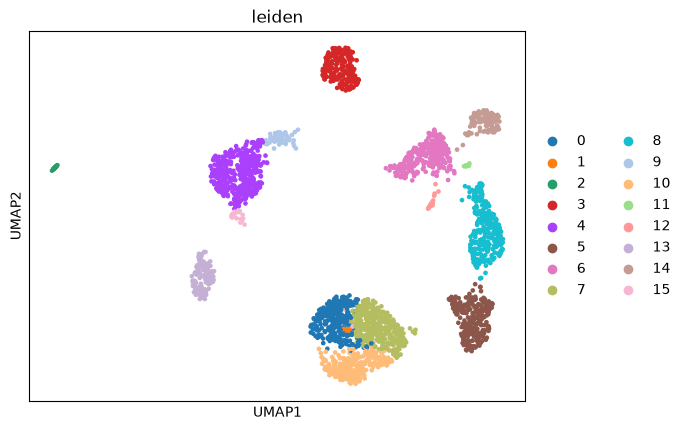

In [22]:
viz.plot_umap(murano_data_best, color="leiden")

In [23]:
ev.get_cluster_summary(murano_data_best)

{'0': 260,
 '1': 6,
 '2': 22,
 '3': 196,
 '4': 405,
 '5': 254,
 '6': 282,
 '7': 353,
 '8': 279,
 '9': 60,
 '10': 255,
 '11': 10,
 '12': 21,
 '13': 142,
 '14': 111,
 '15': 24}